In [54]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.constraints import max_norm
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv('PRSA_Data_Changping.csv',sep = ',')
# the dataset has an extra column for the station, remove it
df = df.drop('station', axis=1)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1


In [56]:
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [57]:
df.isnull().sum(axis = 0)

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,774
PM10,582
SO2,628
NO2,667
CO,1521


In [58]:
df = df.dropna()

In [59]:
# use results of dtypes to determine categorical and numerical features
catFeatures = ['wd']
df[catFeatures].describe(include='all').loc['unique', :]

,unique
wd,16


In [60]:
factors = pd.get_dummies(df[catFeatures], drop_first=True, dtype=int)
factors.head()

,wd_ENE,wd_ESE,wd_N,wd_NE,wd_NNE,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [61]:
df = df.drop(catFeatures, axis=1)
df = pd.concat([df, factors], axis=1)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,...,0,0,0,0,0,0,0,0,0,0
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,...,0,0,0,0,0,0,0,0,0,0
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,...,0,0,0,0,0,0,0,0,0,0
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,...,0,0,0,0,0,0,0,0,0,0
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,...,0,0,0,0,0,0,0,0,0,0


In [62]:
X = df.drop('PM2.5', axis=1)
y = df['PM2.5']

#Split the data into training and test data
from sklearn.model_selection import train_test_split
# 80% of training and 20% of the test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 2021)

In [63]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#Fit and transform the training data
X_train= scaler.fit_transform(X_train)
#Only transform the test data
X_test = scaler.transform(X_test)

The second value in X_train.shape is my feature count.  Use that as the input size for my neural networks.

In [64]:
X_train.shape

(26144, 30)

In [65]:
input_size = X_train.shape[1]
#specify the number of neuron for the first layer
hidden_size = [20, 10]
print(input_size)

30


# TensorFlow

In [66]:
model = keras.Sequential()
model.add(layers.Dense(input_size, activation='relu'))
model.add(layers.Dense(hidden_size[0], activation='relu'))
model.add(layers.Dense(hidden_size[1], activation='relu'))
# Output layer has only one neuron
model.add(layers.Dense(1))

In [67]:
#Configure the model by choosing optimizer and loss function
model.compile(optimizer='adam',loss='mse')

In [68]:
%%time
#Fix the seed
tf.random.set_seed(1)
#Fit the model and save the results in history
history = model.fit(x=X_train,y=y_train,batch_size=64,epochs=500,
          validation_data=(X_test,y_test), verbose=0
          )

CPU times: user 11min 8s, sys: 26.6 s, total: 11min 34s
Wall time: 9min 38s


In [69]:
#Convert the train and validation loss to a df
trainhist = pd.DataFrame(history.history)
#Add the epoch index
trainhist['epoch'] = history.epoch
#Look at the latest performance
trainhist.tail()

,loss,val_loss,epoch
495,314.577271,342.781769,495
496,314.479828,344.178833,496
497,314.715973,343.238617,497
498,314.187592,344.420837,498
499,314.409912,343.324646,499


## Find out if the TensorFlow| model underfits or overfits the data

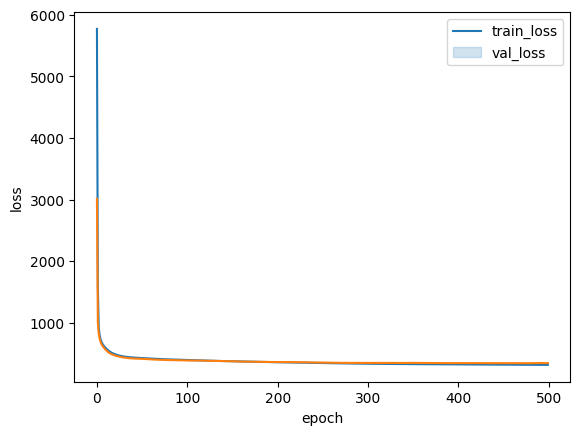

In [70]:
#Plot train loss
sns.lineplot(x='epoch', y ='loss', data =trainhist)
#Plot validation loss
sns.lineplot(x='epoch', y ='val_loss', data =trainhist)
#Add legends
plt.legend(labels=['train_loss', 'val_loss'])

## With 500 epochs, the graph shows Overfitting.  There is a gap between the training loss and validation loss.  The slope is decreasing for the training loss but slightly increasing for the validation loss.  That means the model has learned patterns in the training data that do not apply in the validation data.

# Hyperparameter Tuning

In [71]:
import sys
#Import the library of keras-tuner
import keras_tuner as kt

In [72]:
def model_builder(hp):
  model = keras.Sequential()

  model.add(layers.Dense(30, activation = 'relu'))

  hp_dropout = hp.Float('rate', min_value = 0.2, max_value = 0.8, step = 0.1)

  # first hidden layer with 20 to 50 neurons with a stepsize of 5
  model.add(Dropout(rate = hp_dropout))
  hp_units1 = hp.Int('units_hidden1', min_value = 20, max_value = 50, step = 5)
  model.add(layers.Dense(hp_units1, activation='relu'))

  # second hidden layer with 5 to 10 neurons with a step size of 1
  model.add(Dropout(rate = hp_dropout))
  hp_units2 = hp.Int('units_hidden2', min_value = 5, max_value = 10, step = 1)
  model.add(layers.Dense(hp_units2, activation='relu'))

  # output layer has one and only one neuron
  model.add(layers.Dense(1))

  model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.001),
                loss = 'mse',
                metrics = [tf.keras.metrics.MeanSquaredError()])

  return model

In [73]:
tuner = kt.Hyperband(model_builder, #Specify the model
                     objective = 'val_loss', #Specify the objective funciton
                     max_epochs = 100, #Specify the maximum epochs
                     directory = 'my_dir', #Specify the file path
                     project_name = 'tuningRegression_v2')

Reloading Tuner from my_dir/tuningRegression_v2/tuner0.json


In [74]:
import IPython
#Clear all the training outputs
class ClearTrainingOutput(tf.keras.callbacks.Callback):
  def on_train_end(*args, **kwargs):
    IPython.display.clear_output(wait = True)

In [75]:
#Perform the search on the defined hyperparameter space by specifying the callback to clear the training outputs
tuner.search(X_train, y_train, epochs = 100, validation_data = (X_test,y_test), callbacks = [ClearTrainingOutput()])

In [76]:
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]
#Use f-strings to format the outputs
print(f"""
The optimal number of units in the first hidden layer =  {best_hps.get('units_hidden1')}.
The optimal number of units in the second hidden layer =  {best_hps.get('units_hidden2')}.
The optimal droupout rate in the input layer = {best_hps.get('rate')}
""")


The optimal number of units in the first hidden layer =  40. 
The optimal number of units in the second hidden layer =  6.
The optimal droupout rate in the input layer = 0.2



The optimal number of units in the first hidden layer =  40.
The optimal number of units in the second hidden layer =  6.
The optimal droupout rate in the input layer = 0.2

Create a model with the optimal parameters

In [77]:
optimal_model = tuner.hypermodel.build(best_hps)
optimal_history = optimal_model.fit(X_train, y_train, epochs = 100, validation_data = (X_test,y_test))

Epoch 1/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 3688.4299 - mean_squared_error: 3688.4299 - val_loss: 1051.4800 - val_mean_squared_error: 1051.4800
Epoch 2/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1122.6882 - mean_squared_error: 1122.6882 - val_loss: 804.8107 - val_mean_squared_error: 804.8107
Epoch 3/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 971.8370 - mean_squared_error: 971.8370 - val_loss: 727.5369 - val_mean_squared_error: 727.5369
Epoch 4/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 900.9915 - mean_squared_error: 900.9915 - val_loss: 667.6284 - val_mean_squared_error: 667.6284
Epoch 5/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 856.2559 - mean_squared_error: 856.2559 - val_loss: 631.5954 - val_mean_squared_error: 631.5954
Epoch 6/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 830.8482 - mean_squared_error: 830.8482 - val_loss: 617.1811 - val_mean_squared_error: 617.1811
Epoch 7/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

PyTorch

In [78]:
X_train = torch.tensor(X_train.astype(np.float32))
y_train = torch.tensor(y_train.values.astype(np.float32).reshape(-1,1))

In [79]:
#convert numpy to tensor from_numpy
X_test = torch.from_numpy(X_test.astype(np.float32))

In [80]:
# define the child module class derivated from parent class of torch.nn.Module)
class LinearRegressionModel(torch.nn.Module):
    #define the constructor
    def __init__(self, input_size,  hidden_size, output_size):
        super(LinearRegressionModel, self).__init__()
        self.hidden1 = torch.nn.Linear(input_size, hidden_size[0])
        self.hidden2 = torch.nn.Linear(hidden_size[0], hidden_size[1])
        self.predict = torch.nn.Linear(hidden_size[1], output_size)
    #overife the forward function in this child class
    def forward(self, x):
        x = F.relu(self.hidden1(x))
        x = F.relu(self.hidden2(x))
        y_pred = self.predict(x)
        return y_pred

In [81]:
input_size = X_train.shape[1]
#specify the number of neuron for the first layer
hidden_size = [20, 10]
model = LinearRegressionModel(input_size, hidden_size,  1)

In [82]:
l = nn.MSELoss()

In [83]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

In [84]:
%%time
from sklearn.metrics import mean_squared_error
#fix the random seeds for troch and np
torch.manual_seed(1)
np.random.seed(0)

#set the number of epochs

num_epochs = 100

train_loss = [None]*num_epochs
valadition_loss = [None]*num_epochs
for epoch in range(num_epochs):
    #forward pass
    y_pred = model(X_train.requires_grad_())

    #calculate the loss
    loss= l(y_pred, y_train)
    #Set the gradients to be zero
    optimizer.zero_grad()

    #backward pass: calculate gradients
    loss.backward()

    #update the weights
    optimizer.step()

    #Stop tracking the gradient by calling detach since we don't use it anymore
    y_pred = model(X_test).detach().numpy()
    val_loss = mean_squared_error(y_test,y_pred)
    train_loss[epoch] = loss.item()
    valadition_loss[epoch] = val_loss
    if epoch % 10 == 0:
        print('epoch {0}, loss = {1:.4f} and val_loss = {2:.4f}'.format(epoch, loss.item(), val_loss))

epoch 0, loss = 9930.5977 and val_loss = 9897.9221
epoch 10, loss = 4912.4556 and val_loss = 5026.6033
epoch 20, loss = 4542.1201 and val_loss = 4691.4398
epoch 30, loss = 3818.8032 and val_loss = 3914.5842
epoch 40, loss = 3066.3225 and val_loss = 3077.1672
epoch 50, loss = 2064.7559 and val_loss = 2003.9007
epoch 60, loss = 1405.9330 and val_loss = 1371.6095
epoch 70, loss = 1164.5002 and val_loss = 1119.0101
epoch 80, loss = 1007.8173 and val_loss = 985.1306
epoch 90, loss = 951.2751 and val_loss = 932.4951
CPU times: user 1.41 s, sys: 35.5 ms, total: 1.45 s
Wall time: 1.45 s


In [85]:
#Convert the train and validation loss to a df
trainhist = pd.DataFrame({'train_loss': train_loss, 'val_loss': valadition_loss, 'epoch':np.arange(num_epochs)})
#Look at the latest performance
trainhist.tail()

,train_loss,val_loss,epoch
95,922.511536,901.566106,95
96,917.053467,896.207773,96
97,912.120972,891.154964,97
98,907.564575,886.003881,98
99,903.022278,880.827952,99


Find out if the PyTorch model underfits or overfits the data

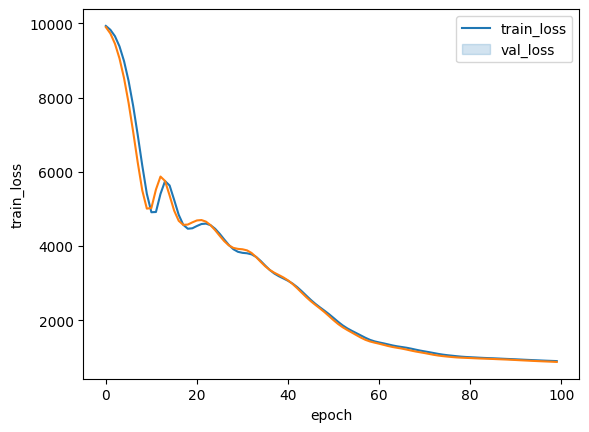

In [86]:
sns.lineplot(x='epoch', y ='train_loss', data =trainhist)
#Plot validation loss
sns.lineplot(x='epoch', y ='val_loss', data =trainhist)
#Add legends
plt.legend(labels=['train_loss', 'val_loss'])

The PyTorch model is not underfit or overfit.  It is well-fitted because the curves move together.